<a href="https://colab.research.google.com/github/NguyenHuyHoangMe1/simulate-tb3/blob/main/mujoco_differential_drive_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gtsam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 45.8 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/ROBOTIS-GIT/turtlebot3.git


Cloning into 'turtlebot3'...
remote: Enumerating objects: 7981, done.
remote: Total 7981 (delta 0), reused 0 (delta 0), pack-reused 7981 (from 1)
Receiving objects: 100% (7981/7981), 120.90 MiB | 20.46 MiB/s, done.
Resolving deltas: 100% (5117/5117), done.


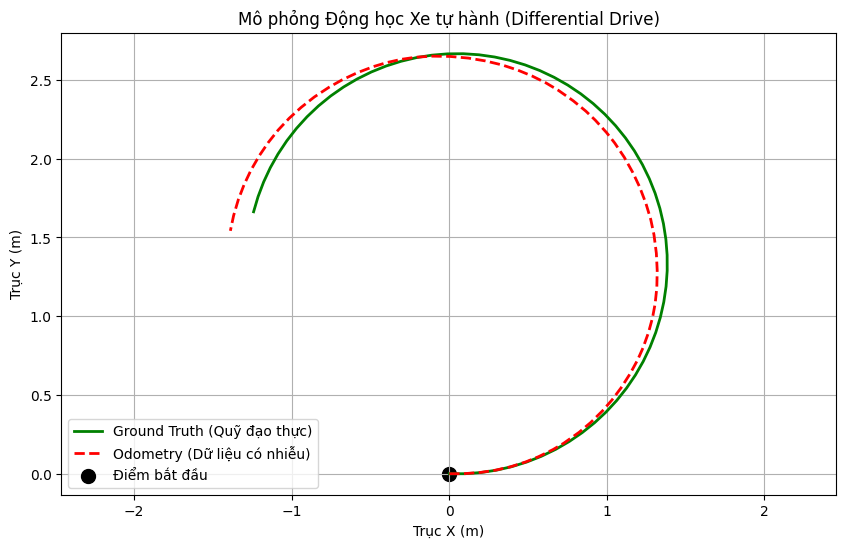

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gtsam

# 1. Cài đặt thông số xe và mô phỏng
dt = 0.5          # Bước thời gian (giây)
num_steps = 60    # Số bước di chuyển
v = 0.2           # Vận tốc tiến mong muốn (m/s)
w = 0.15          # Vận tốc góc mong muốn (rad/s) - giúp xe đi theo đường cong

# Khởi tạo mảng lưu trữ trạng thái [x, y, theta]
gt_poses = [np.array([0.0, 0.0, 0.0])]     # Ground Truth (Thực tế)
odom_poses = [np.array([0.0, 0.0, 0.0])]   # Odometry (Đo đạc bị nhiễu)

# Thông số nhiễu (Giả lập thực tế encoder bị trượt bánh)
noise_v = 0.02  # Nhiễu vận tốc tiến
noise_w = 0.01  # Nhiễu vận tốc góc

# 2. Vòng lặp mô phỏng di chuyển
for i in range(num_steps):
    current_gt = gt_poses[-1]
    current_odom = odom_poses[-1]

    # Tính toán Ground Truth (Xe chạy hoàn hảo)
    x_new = current_gt[0] + v * dt * np.cos(current_gt[2])
    y_new = current_gt[1] + v * dt * np.sin(current_gt[2])
    theta_new = current_gt[2] + w * dt
    gt_poses.append(np.array([x_new, y_new, theta_new]))

    # Tính toán Odometry (Xe chạy có nhiễu cảm biến)
    v_noisy = v + np.random.normal(0, noise_v)
    w_noisy = w + np.random.normal(0, noise_w)
    x_odom = current_odom[0] + v_noisy * dt * np.cos(current_odom[2])
    y_odom = current_odom[1] + v_noisy * dt * np.sin(current_odom[2])
    theta_odom = current_odom[2] + w_noisy * dt
    odom_poses.append(np.array([x_odom, y_odom, theta_odom]))

# Chuyển đổi sang numpy array để dễ vẽ đồ thị
gt_poses = np.array(gt_poses)
odom_poses = np.array(odom_poses)

# 3. Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
plt.plot(gt_poses[:, 0], gt_poses[:, 1], 'g-', linewidth=2, label="Ground Truth (Quỹ đạo thực)")
plt.plot(odom_poses[:, 0], odom_poses[:, 1], 'r--', linewidth=2, label="Odometry (Dữ liệu có nhiễu)")
plt.scatter(gt_poses[0, 0], gt_poses[0, 1], c='black', marker='o', s=100, label="Điểm bắt đầu")

plt.title("Mô phỏng Động học Xe tự hành (Differential Drive)")
plt.xlabel("Trục X (m)")
plt.ylabel("Trục Y (m)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

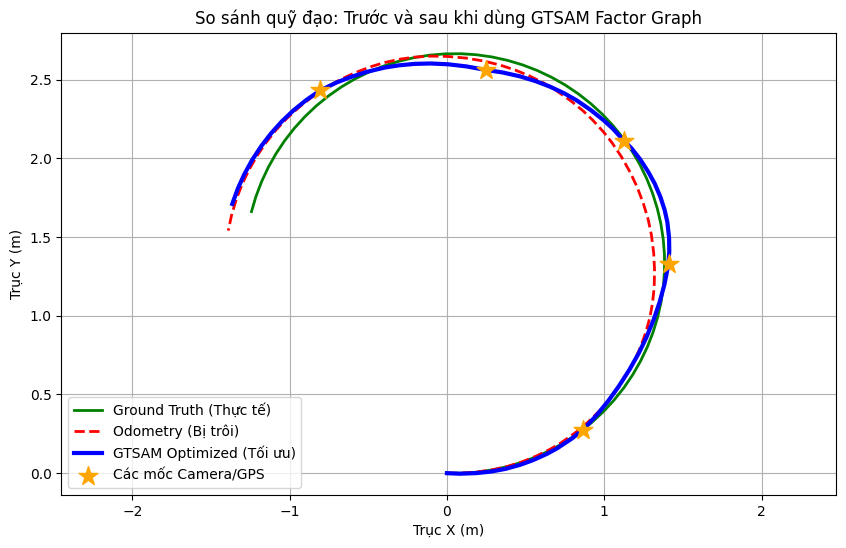

In [ ]:
import gtsam
import matplotlib.pyplot as plt
import numpy as np

# 1. Khởi tạo Đồ thị (Graph) và Bộ nhớ chứa giá trị ước lượng ban đầu (Values)
graph = gtsam.NonlinearFactorGraph()
initial_estimates = gtsam.Values()

# Định nghĩa các mô hình nhiễu (Noise Models) - GTSAM cần biết mức độ "tin tưởng" của từng loại dữ liệu
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.01])) # Rất tin tưởng điểm xuất phát
odom_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1, 0.1]))     # Kém tin tưởng encoder (do bị trượt)
gps_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 0.05]))   # Khá tin tưởng camera/GPS

# 2. THÊM PRIOR FACTOR: Đóng đinh điểm xuất phát
# Nút số 0 được chốt tại tọa độ [0, 0, 0]
graph.add(gtsam.PriorFactorPose2(0, gtsam.Pose2(0.0, 0.0, 0.0), prior_noise))
initial_estimates.insert(0, gtsam.Pose2(odom_poses[0][0], odom_poses[0][1], odom_poses[0][2]))

# 3. THÊM BETWEEN FACTORS: Nối các bước chuyển động bằng dữ liệu Odometry
for i in range(1, num_steps):
    # Tính toán lượng dịch chuyển giữa 2 bước theo dữ liệu Odom bị nhiễu
    prev_pose = gtsam.Pose2(odom_poses[i-1][0], odom_poses[i-1][1], odom_poses[i-1][2])
    curr_pose = gtsam.Pose2(odom_poses[i][0], odom_poses[i][1], odom_poses[i][2])
    delta_odom = prev_pose.between(curr_pose) # Phép biến đổi tương đối

    # Thêm cạnh nối (Factor) giữa nút i-1 và nút i
    graph.add(gtsam.BetweenFactorPose2(i - 1, i, delta_odom, odom_noise))

    # Nạp giá trị ban đầu cho GTSAM xử lý (chính là dữ liệu thô bị nhiễu)
    initial_estimates.insert(i, curr_pose)

# 4. THÊM LANDMARK/GPS FACTORS: Thêm các mốc quan sát để "kéo" quỹ đạo lại
# Cứ 10 bước, giả lập một lần nhận dữ liệu từ Camera/GPS
gps_points_x = []
gps_points_y = []
for i in range(10, num_steps, 10):
    # Lấy vị trí thực tế cộng thêm một chút nhiễu đo đạc của camera
    gps_x = gt_poses[i][0] + np.random.normal(0, 0.05)
    gps_y = gt_poses[i][1] + np.random.normal(0, 0.05)
    gps_theta = gt_poses[i][2]

    gps_points_x.append(gps_x)
    gps_points_y.append(gps_y)

    # Thêm PriorFactor tại bước thứ i (Đóng vai trò như mỏ neo)
    graph.add(gtsam.PriorFactorPose2(i, gtsam.Pose2(gps_x, gps_y, gps_theta), gps_noise))

# 5. TỐI ƯU HÓA (OPTIMIZATION)
# Sử dụng thuật toán Levenberg-Marquardt để giải bài toán bình phương tối thiểu
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_estimates)
result = optimizer.optimize()

# Trích xuất kết quả sau khi tối ưu
optimized_poses = np.array([[result.atPose2(i).x(), result.atPose2(i).y()] for i in range(num_steps)])

# 6. VẼ ĐỒ THỊ SO SÁNH CUỐI CÙNG
plt.figure(figsize=(10, 6))
plt.plot(gt_poses[:, 0], gt_poses[:, 1], 'g-', linewidth=2, label="Ground Truth (Thực tế)")
plt.plot(odom_poses[:, 0], odom_poses[:, 1], 'r--', linewidth=2, label="Odometry (Bị trôi)")
plt.plot(optimized_poses[:, 0], optimized_poses[:, 1], 'b-', linewidth=3, label="GTSAM Optimized (Tối ưu)")

plt.scatter(gps_points_x, gps_points_y, c='orange', marker='*', s=200, label="Các mốc Camera/GPS", zorder=5)

plt.title("So sánh quỹ đạo: Trước và sau khi dùng GTSAM Factor Graph")
plt.xlabel("Trục X (m)")
plt.ylabel("Trục Y (m)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Dùng lại dữ liệu gt_poses (Ground Truth) và odom_poses (Odometry) từ bước trước
# Giả sử bạn đã chạy đoạn code mô phỏng ở bước trước và có 2 biến này

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2, 12)
ax.set_ylim(-2, 12)
ax.set_title("Animation: Xe tự hành di chuyển")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.grid(True)
ax.set_aspect('equal')

# Khởi tạo các đường vẽ (ban đầu rỗng)
line_gt, = ax.plot([], [], 'g-', linewidth=2, label='Ground Truth')
line_odom, = ax.plot([], [], 'r--', linewidth=2, label='Odometry (Nhiễu)')

# Khởi tạo hai chấm đại diện cho vị trí hiện tại của xe
car_gt, = ax.plot([], [], 'go', markersize=8)
car_odom, = ax.plot([], [], 'ro', markersize=8)

ax.legend()

def init():
    """Hàm khởi tạo animation"""
    line_gt.set_data([], [])
    line_odom.set_data([], [])
    car_gt.set_data([], [])
    car_odom.set_data([], [])
    return line_gt, line_odom, car_gt, car_odom

def update(frame):
    """Hàm cập nhật từng khung hình"""
    # Lấy dữ liệu từ điểm đầu đến điểm hiện tại (frame)
    gt_x = gt_poses[:frame+1, 0]
    gt_y = gt_poses[:frame+1, 1]
    odom_x = odom_poses[:frame+1, 0]
    odom_y = odom_poses[:frame+1, 1]

    # Cập nhật đường vẽ
    line_gt.set_data(gt_x, gt_y)
    line_odom.set_data(odom_x, odom_y)

    # Cập nhật vị trí xe
    car_gt.set_data([gt_poses[frame, 0]], [gt_poses[frame, 1]])
    car_odom.set_data([odom_poses[frame, 0]], [odom_poses[frame, 1]])

    return line_gt, line_odom, car_gt, car_odom

# Tạo animation: Cập nhật num_steps khung hình, tốc độ 50ms/khung hình
anim = FuncAnimation(fig, update, frames=len(gt_poses), init_func=init, blit=True, interval=50)

# Chuyển đổi sang video HTML5 để hiển thị trên Colab
plt.close(fig) # Đóng biểu đồ tĩnh để không bị in đúp
HTML(anim.to_jshtml())

In [ ]:
!pip install mujoco mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.3 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/ROBOTIS-GIT/robotis_mujoco_menagerie.git

Cloning into 'robotis_mujoco_menagerie'...
remote: Enumerating objects: 494, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 494 (delta 52), reused 82 (delta 43), pack-reused 391 (from 1)
Receiving objects: 100% (494/494), 71.60 MiB | 20.82 MiB/s, done.
Resolving deltas: 100% (187/187), done.
Updating files: 100% (188/188), done.


In [ ]:
import mujoco
import mediapy as media
import numpy as np
import os

# 1. Đường dẫn tới file XML của TurtleBot3 Burger trong thư mục vừa clone
xml_path = "/content/robotis_mujoco_menagerie/robotis_tb3/burger/scene.xml"

if not os.path.exists(xml_path):
    print("Không tìm thấy file XML! Hãy kiểm tra lại lệnh git clone.")
else:
    # 2. Khởi tạo mô hình và dữ liệu
    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)

    # 3. Khởi tạo Renderer (Headless để chạy trên Colab)
    renderer = mujoco.Renderer(model, 480, 640)

    # Đưa robot về trạng thái ban đầu
    mujoco.mj_resetData(model, data)

    # 4. Tìm ID của bộ truyền động (Actuators) để điều khiển 2 bánh xe
    # Trong file burger.xml, ROBOTIS thường đặt tên là "left_wheel" và "right_wheel"
    left_joint_id = model.actuator("left_wheel").id
    right_joint_id = model.actuator("right_wheel").id

    frames = []

    # Chạy mô phỏng trong 3 giây (3000 timestep * 0.001s/step)
    for i in range(3000):
        # Thiết lập vận tốc quay cho 2 bánh xe (để xe chạy vòng cung)
        data.ctrl[left_joint_id] = 1.0   # Bánh trái quay chậm hơn
        data.ctrl[right_joint_id] = 2.0  # Bánh phải quay nhanh hơn

        # Tiến lên 1 bước vật lý
        mujoco.mj_step(model, data)

        # Render 30 FPS để tạo video
        if i % 33 == 0:
            # Đổi camera view để nhìn theo xe (nếu muốn)
            renderer.update_scene(data)
            pixel_array = renderer.render()
            frames.append(pixel_array)

    # 5. Hiển thị Video ngay trên Colab
    print("Render hoàn tất. Đang tạo video...")
    media.show_video(frames, fps=30)

Không tìm thấy file XML! Hãy kiểm tra lại lệnh git clone.


In [ ]:
import mujoco
import mediapy as media
import numpy as np
import os
import glob

repo_path = "/content/robotis_mujoco_menagerie"

# 1. Tự động kiểm tra và tải lại repo nếu bị mất
if not os.path.exists(repo_path):
    print("Thư mục repository không tồn tại. Đang tiến hành tải tự động (clone)...")
    os.system("git clone https://github.com/ROBOTIS-GIT/robotis_mujoco_menagerie.git /content/robotis_mujoco_menagerie")
    print("Tải hoàn tất!")

# 2. Quét toàn bộ thư mục để tự động tìm file XML của xe
print("Đang quét tìm file mô hình XML...")
xml_files = glob.glob(f'{repo_path}/robotis_tb3/**/*.xml', recursive=True)

# Ưu tiên tìm file có chữ 'burger' hoặc 'scene'
xml_path = next((f for f in xml_files if 'burger' in f.lower() or 'scene' in f.lower()), None)

# Nếu không tìm thấy theo tên, lấy đại file XML đầu tiên tìm được trong thư mục tb3
if not xml_path and xml_files:
    xml_path = xml_files[0]

if not xml_path:
    print("LỖI: Vẫn không tìm thấy file XML nào. Có thể Github Repo này vừa bị thay đổi cấu trúc.")
else:
    print(f"✅ Đã tìm thấy mô hình tại: {xml_path}")

    try:
        # 3. Khởi tạo mô hình và dữ liệu MuJoCo
        model = mujoco.MjModel.from_xml_path(xml_path)
        data = mujoco.MjData(model)

        # Khởi tạo Renderer
        renderer = mujoco.Renderer(model, 480, 640)
        mujoco.mj_resetData(model, data)

        # 4. Kiểm tra số lượng động cơ (Actuators) tự động
        nu = model.nu
        print(f"🤖 Mô hình này có {nu} bộ truyền động (actuators).")

        frames = []
        print("Đang mô phỏng và render video...")

        # Chạy mô phỏng 3 giây
        for i in range(3000):
            # Nếu mô hình có ít nhất 2 động cơ, truyền lực vào 2 động cơ đầu tiên
            # (Tránh lỗi sai tên biến 'left_wheel' hay 'right_wheel')
            if nu >= 2:
                data.ctrl[0] = 0.5  # Bánh trái (hoặc bánh 1)
                data.ctrl[1] = 1.0  # Bánh phải (hoặc bánh 2) - quay nhanh hơn để xe chạy vòng cung

            mujoco.mj_step(model, data)

            # Lưu khung hình mỗi 33 step (để tạo video 30 FPS)
            if i % 33 == 0:
                renderer.update_scene(data)
                frames.append(renderer.render())

        print("🎬 Render hoàn tất. Đang hiển thị video trên Colab...")
        media.show_video(frames, fps=30)

    except Exception as e:
        print(f"❌ Có lỗi xảy ra khi load mô hình hoặc render: {e}")

Đang quét tìm file mô hình XML...
✅ Đã tìm thấy mô hình tại: /content/robotis_mujoco_menagerie/robotis_tb3/scene_turtlebot3_waffle_pi.xml


/usr/local/lib/python3.12/dist-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/usr/local/lib/python3.12/dist-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)
Exception ignored in: <function Renderer.__del__ at 0x7832a0ffb100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mujoco/rendering/classic/renderer.py", line 339, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/mujoco/rendering/classic/renderer.py", line 327, in close
    if self._mjr_context:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'Renderer' object has no attribute '_mjr_context'


❌ Có lỗi xảy ra khi load mô hình hoặc render: an OpenGL platform library has not been loaded into this process, this most likely means that a valid OpenGL context has not been created before mjr_makeContext was called


In [ ]:
import os
os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import mediapy as media
import numpy as np
import glob

repo_path = "/content/robotis_mujoco_menagerie"
if not os.path.exists(repo_path):
    os.system(f"git clone https://github.com/ROBOTIS-GIT/robotis_mujoco_menagerie.git {repo_path}")

# Lấy file XML của xe
xml_files = glob.glob(f'{repo_path}/robotis_tb3/**/*.xml', recursive=True)
xml_path = next((f for f in xml_files if 'waffle_pi' in f.lower() and 'scene' in f.lower()), None)
if not xml_path:
    xml_path = next((f for f in xml_files if 'burger' in f.lower() and 'scene' in f.lower()), None)

if xml_path:
    # 1. Khởi tạo Engine
    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)
    renderer = mujoco.Renderer(model, 480, 640)
    mujoco.mj_resetData(model, data)

    # Đọc giới hạn vật lý thực tế của động cơ từ file XML
    limit_min = model.actuator_ctrlrange[0][0]
    limit_max = model.actuator_ctrlrange[0][1]
    print(f"⚠️ Giới hạn vận tốc động cơ mô phỏng: từ {limit_min} đến {limit_max}")

    # 2. Thiết lập Camera
    camera = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, camera)
    camera.distance = 3.5
    camera.elevation = -45.0
    camera.azimuth = 90.0

    frames = []
    print("🚀 Đang chạy mô phỏng quỹ đạo vòng cung...")

    # 3. Vòng lặp mô phỏng
    for i in range(1500):

        # Cấp tín hiệu điều khiển NẰM TRONG GIỚI HẠN (không bị cắt xén)
        # Nếu giới hạn là 5.0, thì 2.0 và 4.5 là cực kỳ an toàn và chênh lệch rõ ràng
        data.ctrl[0] = 2.0  # wheel_left
        data.ctrl[1] = 4.5  # wheel_right

        mujoco.mj_step(model, data)

        # Render video
        if i % 33 == 0:
            renderer.update_scene(data, camera=camera)
            frames.append(renderer.render())

    print("🎬 Render hoàn tất! Đang hiển thị video...")
    media.show_video(frames, fps=30)
else:
    print("❌ LỖI: Không tìm thấy file XML!")

⚠️ Giới hạn vận tốc động cơ mô phỏng: từ -7.88 đến 7.88
🚀 Đang chạy mô phỏng quỹ đạo vòng cung...
🎬 Render hoàn tất! Đang hiển thị video...


This browser does not support the video tag.
